<a href="https://colab.research.google.com/github/sjkim0520/Mechanical_Project/blob/main/Semiconductor/03_Cu_CMP_RSM_Optimization/Step2_%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%83%9D%EC%84%B1%EA%B3%BC_2%EC%B0%A8%ED%9A%8C%EA%B7%80%EB%AA%A8%EB%8D%B8%EB%A7%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📗 Day 3~4. 가상 CMP 실험 데이터 생성 &amp; 2차 회귀 모델링

**프로젝트 3. HBM 구리(Cu) 하이브리드 본딩 CMP 공정 조건 RSM 최적화**

오늘의 목표는 두 가지입니다.
1. **중심합성설계(Central Composite Design, CCD)**로 실험 조건표(설계행렬)를 직접 만들기
2. Preston 방정식을 확장한 "숨겨진 진짜 모델"로 가상의 실험 결과(표면조도 Ra, 디싱 깊이)를 생성하고, `scikit-learn` / `statsmodels`로 2차 회귀모델을 적합하기

> 참고문헌: NIST/SEMATECH e-Handbook of Statistical Methods, *"5.3.3.6. Response surface designs"*, https://itl.nist.gov/div898/handbook/pri/section3/pri336.htm — CCD와 Box-Behnken 설계의 표준 설명이 정리되어 있는 무료 온라인 자료입니다.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

np.random.seed(2)
pd.set_option('display.precision', 3)

## 1. 공정변수 정의

이번 프로젝트에서는 Cu CMP 공정의 대표적인 3개 변수를 사용합니다. (실제 공정에서는 슬러리 pH, 패드 컨디셔닝 등을 더 추가할 수 있지만, 3변수로도 RSM의 핵심 개념을 충분히 익힐 수 있습니다.)

| 기호 | 변수 | 단위 | 저준위(-1) | 중심(0) | 고준위(+1) |
|---|---|---|---|---|---|
| $x_1$ | 연마 압력 (Pressure) | psi | 2.0 | 4.0 | 6.0 |
| $x_2$ | 패드 회전 속도 (Velocity) | rpm | 40 | 70 | 100 |
| $x_3$ | 슬러리 유량 (Slurry Flow) | mL/min | 100 | 150 | 200 |

RSM에서는 변수의 실제 단위(psi, rpm, mL/min) 대신, 위 표처럼 **-1(저), 0(중심), +1(고)**로 코드화(coding)하여 계산합니다. 이렇게 하면 서로 단위가 다른 변수들을 공평하게 비교하고 회귀 계수의 크기로 영향력을 바로 해석할 수 있습니다.

코드화 공식은 다음과 같습니다.

$$
x_{coded} = \frac{x_{actual} - x_{center}}{(x_{high}-x_{low})/2}
$$


In [3]:
# 실제 단위 <-> 코드화 단위 변환 함수
levels = {
    'Pressure':   {'low': 2.0, 'center': 4.0, 'high': 6.0,   'unit': 'psi'},
    'Velocity':   {'low': 40,  'center': 70,  'high': 100,   'unit': 'rpm'},
    'SlurryFlow': {'low': 100, 'center': 150, 'high': 200,   'unit': 'mL/min'},
}

def to_actual(coded_val, factor):
    lo, hi = levels[factor]['low'], levels[factor]['high']
    center = levels[factor]['center']
    half_range = (hi - lo) / 2
    return center + coded_val * half_range

for f in levels:
    print(f, '  -1 ->', to_actual(-1, f), '   0 ->', to_actual(0, f), '   +1 ->', to_actual(1, f))


Pressure   -1 -> 2.0    0 -> 4.0    +1 -> 6.0
Velocity   -1 -> 40.0    0 -> 70.0    +1 -> 100.0
SlurryFlow   -1 -> 100.0    0 -> 150.0    +1 -> 200.0


## 2. 중심합성설계(CCD) 실험점 생성

3변수 CCD는 다음 3종류의 점으로 구성됩니다.

- **요인점(Factorial points)**: $2^k$개, 모든 변수가 $\pm 1$ 조합 ($k=3$이므로 $2^3=8$개)
- **축점(Axial / star points)**: $2k$개, 한 변수만 $\pm \alpha$이고 나머지는 0 (회전성을 갖도록 $\alpha = (2^k)^{1/4}$로 계산, $k=3$이면 $\alpha \approx 1.682$)
- **중심점(Center points)**: 보통 3~6회 반복 측정하여 순수오차(pure error)를 추정 (여기서는 5회 사용)

총 실험 횟수는 $8 + 6 + 5 = 19$회가 됩니다.


In [4]:
k = 3
alpha = (2**k) ** 0.25   # 회전성(rotatability)을 만족하는 축거리
n_center = 5

# TODO 1: 요인점(factorial points)을 생성하세요.
#         itertools.product([-1, 1], repeat=3) 을 사용하면 (-1,-1,-1)부터 (1,1,1)까지 8개 조합이 나옵니다.
factorial_points = list(product([-1,1],repeat=3))

# TODO 2: 축점(axial points)을 생성하세요. 총 6개: (+-alpha,0,0), (0,+-alpha,0), (0,0,+-alpha)
#         아래 리스트를 완성하세요.
axial_points = [
    ( alpha, 0, 0), (-alpha, 0, 0),
    (0, alpha,0), (0, -alpha,0),   # (0, +-alpha, 0) 두 개를 채우세요
    (0,0,alpha), (0,0,-alpha)   # (0, 0, +-alpha) 두 개를 채우세요
]

center_points = [(0, 0, 0)] * n_center

design_coded = np.array(list(factorial_points) + axial_points + list(center_points), dtype=float)
print("총 실험 횟수:", design_coded.shape[0])


총 실험 횟수: 19


In [5]:
# 코드화 값을 실제 물리 단위로 변환하여 실험계획표(DOE table)를 완성합니다.
df = pd.DataFrame(design_coded, columns=['x1_coded', 'x2_coded', 'x3_coded'])
df['Pressure_psi']    = df['x1_coded'].apply(lambda v: to_actual(v, 'Pressure'))
df['Velocity_rpm']    = df['x2_coded'].apply(lambda v: to_actual(v, 'Velocity'))
df['SlurryFlow_mLmin']= df['x3_coded'].apply(lambda v: to_actual(v, 'SlurryFlow'))
df['RunOrder'] = np.arange(1, len(df) + 1)
df = df.set_index('RunOrder')
df.round(2)

,x1_coded,x2_coded,x3_coded,Pressure_psi,Velocity_rpm,SlurryFlow_mLmin
RunOrder,,,,,,
1,-1.00,-1.00,-1.00,2.00,40.00,100.00
2,-1.00,-1.00,1.00,2.00,40.00,200.00
3,-1.00,1.00,-1.00,2.00,100.00,100.00
4,-1.00,1.00,1.00,2.00,100.00,200.00
5,1.00,-1.00,-1.00,6.00,40.00,100.00
6,1.00,-1.00,1.00,6.00,40.00,200.00
7,1.00,1.00,-1.00,6.00,100.00,100.00
8,1.00,1.00,1.00,6.00,100.00,200.00
9,1.68,0.00,0.00,7.36,70.00,150.00


## 3. '숨겨진 진짜 모델'로 가상 실험 결과 생성하기

실제로는 이 단계에서 CMP 장비로 웨이퍼를 연마하고 표면을 측정하겠지만, 여기서는 **미리 정해둔 진짜 물리 관계식 + 노이즈**로 데이터를 시뮬레이션합니다. (문헌에서 보고되는 경향, 즉 압력이 커질수록 MRR과 디싱이 함께 증가하고, 유량이 부족하면 표면조도가 나빠지는 경향을 반영해 계수를 설계했습니다.)

**표면조도(Ra, nm)** — 슬러리 유량이 부족하고 속도가 너무 빠르면 나빠지는 경향을 반영:

$$
Ra = 8 + 1.4x_1 - 0.6x_3 + 0.9x_1^2 + 0.5x_2^2 - 0.7x_1x_3 + \varepsilon_{Ra}
$$

**디싱 깊이(Dishing, nm)** — Preston 방정식(압력×속도에 비례하는 MRR)이 커질수록, 특히 압력이 클수록 급격히 증가하는 비선형 경향을 반영:

$$
Dishing = 15 + 6x_1 + 3x_2 - 1.5x_3 + 2.2x_1^2 + 1.1x_1x_2 + \varepsilon_{D}
$$


In [6]:
def true_Ra(x1, x2, x3, noise_sd=0.4):
    # TODO 3: 위 Ra 수식을 그대로 옮겨 계산하세요. noise_sd를 표준편차로 하는 정규분포 노이즈를 더하세요.
    base = 8+1.4*x1-0.6*x3+0.9*x1**2+0.5*x2**2-0.7*x1*x3+noise_sd
    noise = np.random.normal(0, noise_sd, size=np.shape(x1))
    return base + noise

def true_dishing(x1, x2, x3, noise_sd=1.2):
    # TODO 4: 위 Dishing 수식을 그대로 옮겨 계산하세요. noise_sd를 표준편차로 하는 정규분포 노이즈를 더하세요.
    base = 15+6*x1+3*x2-1.5*x3+2.2*x1**2+1.1*x1*x2+noise_sd
    noise = np.random.normal(0, noise_sd, size=np.shape(x1))
    return base + noise

def true_MRR(x1, x2, x3, Kp=2.1, noise_sd=3.0):
    # Preston 방정식 기반 MRR (참고용으로 이미 완성되어 있습니다)
    # 실제 압력/속도(코드화 -1~1 -> 실제 단위)로 환산해서 계산합니다.
    P = to_actual(x1, 'Pressure')
    V = to_actual(x2, 'Velocity')
    mrr = Kp * P * V
    noise = np.random.normal(0, noise_sd, size=np.shape(x1))
    return mrr + noise

df['Ra_nm'] = true_Ra(df['x1_coded'].values, df['x2_coded'].values, df['x3_coded'].values)
df['Dishing_nm'] = true_dishing(df['x1_coded'].values, df['x2_coded'].values, df['x3_coded'].values)
df['MRR_nm_per_min'] = true_MRR(df['x1_coded'].values, df['x2_coded'].values, df['x3_coded'].values)

df[['Pressure_psi','Velocity_rpm','SlurryFlow_mLmin','Ra_nm','Dishing_nm','MRR_nm_per_min']].round(2)


,Pressure_psi,Velocity_rpm,SlurryFlow_mLmin,Ra_nm,Dishing_nm,MRR_nm_per_min
RunOrder,,,,,,
1,2.00,40.00,100.00,8.13,12.01,168.00
2,2.00,40.00,200.00,8.48,7.95,169.63
3,2.00,100.00,100.00,7.45,15.61,419.06
4,2.00,100.00,200.00,9.16,13.11,422.31
5,6.00,40.00,100.00,11.78,20.61,498.40
6,6.00,40.00,200.00,9.56,18.39,509.19
7,6.00,100.00,100.00,12.70,29.72,1264.40
8,6.00,100.00,200.00,9.40,26.23,1258.99
9,7.36,70.00,150.00,12.88,31.09,1084.28


## 4. scikit-learn으로 2차 회귀모델 자동 적합

Day1~2에서 손으로 풀었던 정규방정식을, 이번엔 `PolynomialFeatures` + `LinearRegression`으로 자동화합니다.
`PolynomialFeatures(degree=2, include_bias=False)`는 $[x_1, x_2, x_3]$로부터 $[x_1, x_2, x_3, x_1^2, x_2^2, x_3^2, x_1x_2, x_1x_3, x_2x_3]$ 항을 자동으로 만들어줍니다.


In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_coded = df[['x1_coded', 'x2_coded', 'x3_coded']].values

# TODO 5: PolynomialFeatures를 degree=2로 생성하고, X_coded에 fit_transform 하세요.
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_coded)

print("항 이름:", poly.get_feature_names_out(['x1', 'x2', 'x3']))
print("변환된 설계행렬 크기:", X_poly.shape)


항 이름: ['x1' 'x2' 'x3' 'x1^2' 'x1 x2' 'x1 x3' 'x2^2' 'x2 x3' 'x3^2']
변환된 설계행렬 크기: (19, 9)


In [9]:
def fit_rsm(y):
    # TODO 6: LinearRegression 모델을 만들고 X_poly, y로 학습(fit)한 뒤,
    #         예측값 y_pred과 R^2 점수를 계산해서 (model, y_pred, r2) 를 반환하세요.
    model = LinearRegression()
    model.fit(X_poly, y)
    y_pred = model.predict(X_poly)
    r2 = r2_score(y,y_pred)
    return model, y_pred, r2

model_Ra, pred_Ra, r2_Ra = fit_rsm(df['Ra_nm'].values)
model_Dish, pred_Dish, r2_Dish = fit_rsm(df['Dishing_nm'].values)
model_MRR, pred_MRR, r2_MRR = fit_rsm(df['MRR_nm_per_min'].values)

print(f"Ra 모델      R^2 = {r2_Ra:.4f}")
print(f"Dishing 모델 R^2 = {r2_Dish:.4f}")
print(f"MRR 모델     R^2 = {r2_MRR:.4f}")


Ra 모델      R^2 = 0.9660
Dishing 모델 R^2 = 0.9783
MRR 모델     R^2 = 1.0000


## 5. statsmodels로 ANOVA / p-value 확인하기

`scikit-learn`은 예측에 특화되어 있지만, 어떤 항이 통계적으로 유의한지(p-value) 보려면 `statsmodels`가 편리합니다.
p-value가 0.05보다 작으면 "그 항이 반응에 유의한 영향을 준다"고 해석합니다.


In [10]:
import statsmodels.api as sm

def fit_ols_summary(y, label):
    X_with_const = sm.add_constant(X_poly)
    # TODO 7: statsmodels의 OLS(Ordinary Least Squares)로 모델을 만들고 학습하세요.
    #         sm.OLS(y, X_with_const) 형태로 만든 뒤 .fit() 을 호출합니다.
    ols_model = sm.OLS(y,X_with_const).fit()
    print(f"===== {label} ANOVA/회귀 결과 =====")
    print(ols_model.summary())
    return ols_model

ols_Ra = fit_ols_summary(df['Ra_nm'].values, "Ra (표면조도)")


===== Ra (표면조도) ANOVA/회귀 결과 =====
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     28.39
Date:                Mon, 17 Aug 2026   Prob (F-statistic):           1.48e-05
Time:                        10:02:38   Log-Likelihood:                -3.5975
No. Observations:                  19   AIC:                             27.20
Df Residuals:                       9   BIC:                             36.64
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.4

In [11]:
ols_Dish = fit_ols_summary(df['Dishing_nm'].values, "Dishing (디싱 깊이)")


===== Dishing (디싱 깊이) ANOVA/회귀 결과 =====
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     45.09
Date:                Mon, 17 Aug 2026   Prob (F-statistic):           2.03e-06
Time:                        10:02:42   Log-Likelihood:                -24.578
No. Observations:                  19   AIC:                             69.16
Df Residuals:                       9   BIC:                             78.60
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

### 결과 해석 가이드 (초급자용)

- `R-squared`: 모델이 데이터 변동의 몇 %를 설명하는지 (1에 가까울수록 좋음, CMP 공정 데이터는 보통 0.85~0.99 정도면 우수)
- `Adj. R-squared`: 항이 늘어나도 불이익을 주는 보정된 R² (여러 모델 비교 시 이것을 우선 봅니다)
- `coef` 열: 각 항의 회귀계수 $\hat\beta$
- `P>|t|` 열: 해당 항의 p-value. **0.05보다 작으면 "유의함"**으로 판단, 크면 그 항은 모델에서 제거를 고려
- `F-statistic` / `Prob (F-statistic)`: 모델 전체가 통계적으로 유의한지에 대한 검정 (ANOVA의 핵심)

> 참고: 실제 논문/보고서에서는 `Lack-of-Fit test`(적합결여 검정)를 추가로 수행해 "2차식이 정말 충분한 근사인지, 3차 이상 항이 필요한지"를 확인합니다. 관심 있다면 NIST 핸드북의 5.3.3.4절을 참고하세요.


## 6. 잔차(Residual) 진단

좋은 회귀모델이라면 잔차(관측값-예측값)가 특정 패턴 없이 무작위로 흩어져야 합니다.


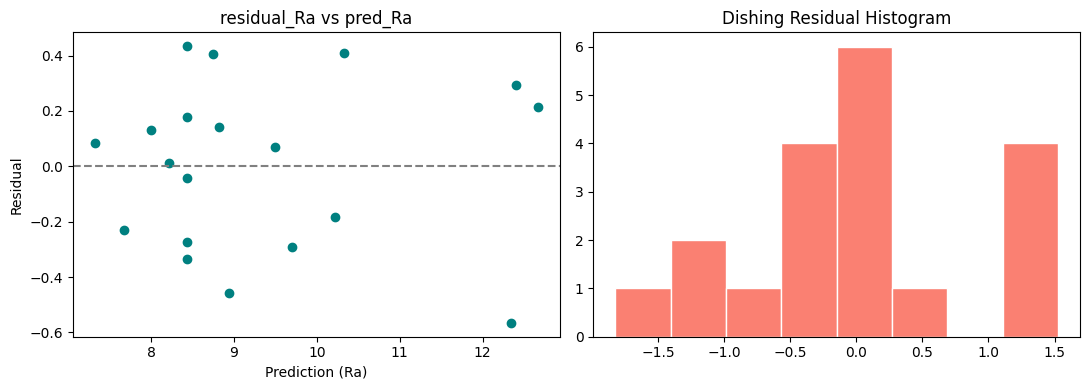

In [14]:
residual_Ra = df['Ra_nm'].values - pred_Ra
residual_Dish = df['Dishing_nm'].values - pred_Dish

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# TODO 8: 왼쪽 그래프에는 Ra의 (예측값 vs 잔차) 산점도를, 오른쪽에는 Dishing의 잔차 히스토그램을 그리세요.
axes[0].scatter(pred_Ra, residual_Ra, color='teal')
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_xlabel('Prediction (Ra)')
axes[0].set_ylabel('Residual')
axes[0].set_title('residual_Ra vs pred_Ra')

axes[1].hist(residual_Dish, bins=8, color='salmon', edgecolor='white')
axes[1].set_title('Dishing Residual Histogram')

plt.tight_layout()
plt.show()


## 7. 오늘의 정리 &amp; 다음 단계

- CCD로 19번의 실험 조건을 설계했고, 이는 만약 모든 변수 조합을 3수준 완전요인설계($3^3=27$)로 했을 때보다 실험 횟수를 줄이면서도 2차 모델을 추정하기에 충분한 정보를 제공합니다.
- Ra, Dishing 각각에 대해 2차 회귀모델(반응표면)을 얻었습니다.
- p-value를 통해 어떤 항(주효과/교호작용/2차항)이 실제로 중요한지 확인했습니다.

**Day 5~7 예고**: 이제 이 두 모델을 동시에 만족시키는 "Dishing은 최소, MRR은 최대"인 공정 조건을 수학적으로 찾고(전역 최적화), 등고선(Contour) 그래프로 시각화합니다.
